In [1]:
import os
import glob 
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.spatial.distance import cdist
from profsea.emulator import AntarcticaISMIP6

In [2]:
def sample_members_2D(array: np.ndarray, percentiles: list | np.ndarray) -> np.ndarray:
    """Sample real ensemble members from a 2D numpy array."""
    array_percentiles = np.percentile(array, percentiles, axis=0)
    distances = cdist(array_percentiles, array)
    mem_indices = np.argmin(distances, axis=1)
    return array[mem_indices]

def load_global_temperature(path: str) -> np.array:
    ds = xr.open_mfdataset(path).tas
    ds = ds.groupby('time.year').mean('time')
    global_weights = np.cos(np.deg2rad(ds.lat))
    ds = ds.weighted(global_weights).mean(dim=['lat', 'lon']).compute()
    tas = ds.sel(year=slice(2015, 2299)).values
    tas -= tas[0]
    return tas

def load_stable_temperature(path: str) -> np.array:
    tas = xr.open_mfdataset(path).tas.values
    tas -= tas[0]
    return tas

def load_var(path: str, variable: str, subtract_control=True) -> np.array:
    control_files = sorted(glob.glob("../data/AIS/ctrlAE/sle_goelzer/*.nc"))
    files = sorted(glob.glob(path))
    anoms = []
    
    for f_idx, file in enumerate(files):
        ds = xr.open_dataset(file, decode_times=False)[f'{variable}']
        ds = ds.sel(time=slice(2015, 2299)).values
        ds -= ds[0]
        
        if subtract_control:
            # Ensure we don't go out of bounds if fewer controls than files
            if f_idx < len(control_files):
                ctrl = xr.open_dataset(control_files[f_idx], decode_times=False)[f"{variable}"]
                ctrl = ctrl.sel(time=slice(2015, 2299)).values
                ctrl -= ctrl[0]
                ds -= ctrl
        
        anoms.append(ds)
    
    # Return array of shape (n_members, n_timesteps)
    return np.array(anoms)

def get_model_name(path: str):
    return path.split("/")[-1].split("sle_AIS_")[-1].split("_exp")[0]

def get_common_models(ais_path: str, variable: str, model_pool: list) -> np.array:
    exp_paths = sorted(glob.glob(os.path.join(ais_path, "expAE*")))

    for idx, exp in enumerate(exp_paths):
        models_path = os.path.join(exp, "sle/*.nc")
        model_exps = sorted(glob.glob(models_path))
        
        model_names = [get_model_name(path) for path in model_exps]

        # check if name in common_models, if not, remove from common models
        for model in model_pool: 
            if model not in model_names:
                model_pool.remove(model)
    return model_pool

SCENARIOS_TRAIN = [
    (load_global_temperature, '../data/AIS/forcing/global/CESM2-WACCM/*.nc', 'expAE04'),       # High (585)
    (load_global_temperature, '../data/AIS/forcing/global/CCSM4/*.nc', 'expAE02'),             # High (85)
    (load_global_temperature, '../data/AIS/forcing/global/HadGEM2-ES/*.nc', 'expAE03'),        # High (85)
    (load_global_temperature, '../data/AIS/forcing/global/UKESM1-0-LL/*.nc', 'expAE05'),       # High (585)
    (load_stable_temperature, '../data/AIS/forcing/global/NorESM1-M_STABLE/tas_Amon_NorESM1-M_rcp26_stabilised.nc', 'expAE01'), # Low (26)
    (load_stable_temperature, '../data/AIS/forcing/global/UKESM1-0-LL_STABLE/*.nc', 'expAE06'), # Stable (585)
]

SCENARIOS_TEST = [
    (load_stable_temperature, '../data/AIS/forcing/global/NorESM1-M_STABLE/tas_Amon_NorESM1-M_rcp85_stabilised.nc', 'expAE07'), # Stable (85)
    (load_stable_temperature, '../data/AIS/forcing/global/HadGEM2-ES_STABLE/*.nc', 'expAE08'), # Stable (85)
    (load_stable_temperature, '../data/AIS/forcing/global/CESM2-WACCM_STABLE/*.nc', 'expAE09'),# Stable (585)
    (load_global_temperature, '../data/AIS/forcing/global/UKESM1-0-LL_126/*.nc', 'expAE10'),   # Low (26)
]

# 1. Load Temperature (Global - same for all regions)
print("Loading Global Temperatures...")
tas_train_list = [loader(path) for loader, path, _ in SCENARIOS_TRAIN]
tas_test_list  = [loader(path) for loader, path, _ in SCENARIOS_TEST]

# Calculate Integrated Temperature
tint_train_list = [np.cumsum(t) for t in tas_train_list]
tint_test_list  = [np.cumsum(t) for t in tas_test_list]

# Convert TAS to numpy arrays (Shape: [n_scenarios, time])
tas_train_arr = np.array(tas_train_list)
tas_test_arr  = np.array(tas_test_list)
tint_train_arr = np.array(tint_train_list)
tint_test_arr  = np.array(tint_test_list)

# 2. Load SLE per Region and Build Dictionaries
regions = [1, 2, 3]
train = {}
test = {}

print("Loading Regional SLE Data...")
for region in regions:
    var_name = f'sle_goelzer_region_{region}'
    print(f"  Processing Region {region}...")

    # Load Train SLE
    sle_train_list = []
    for _, _, exp_id in SCENARIOS_TRAIN:
        path = f'../data/AIS/{exp_id}/sle_goelzer/*.nc'
        sle_data = load_var(path, variable=var_name)
        sle_train_list.append(sle_data)
    
    # Load Test SLE
    sle_test_list = []
    for _, _, exp_id in SCENARIOS_TEST:
        path = f'../data/AIS/{exp_id}/sle_goelzer/*.nc'
        sle_data = load_var(path, variable=var_name)
        sle_test_list.append(sle_data)

    # Convert to object array or structured array depending on member count consistency
    # (Using np.array with dtype=object allows varying member counts per model if necessary)
    # If all models have same member count, you can remove dtype=object
    sle_train_arr = np.array(sle_train_list, dtype=object) 
    sle_test_arr = np.array(sle_test_list, dtype=object)

    # Populate Dictionaries
    train[region] = {
        'tas': tas_train_arr,
        't_int': tint_train_arr,
        'sle': sle_train_arr
    }

    test[region] = {
        'tas': tas_test_arr,
        't_int': tint_test_arr,
        'sle': sle_test_arr
    }

model_list = sorted(glob.glob('../data/AIS/expAE04/sle_goelzer/*.nc'))
model_names = [item.split("/")[-1].split("sle_goelzer_AIS_")[-1].split("_exp")[0] for item in model_list]
common_models = get_common_models("../data/AIS/", "sle", model_names.copy())
common_idx = [model_names.index(item) for item in common_models if item in model_names]

print("Data loading complete.")

Loading Global Temperatures...
Loading Regional SLE Data...
  Processing Region 1...
  Processing Region 2...
  Processing Region 3...
Data loading complete.


In [17]:
wa_ais = AntarcticaISMIP6("wa_params_JAN.nc")
ea_ais = AntarcticaISMIP6("ea_params_JAN.nc")
pen_ais = AntarcticaISMIP6("pen_params_JAN.nc")

# The region number doesn't matter for tas and t_int
wa_train_preds = [wa_ais.predict(train[1]["tas"][scen], train[1]["t_int"][scen], display_progress=False) for scen in range(train[1]["tas"].shape[0])]
ea_train_preds = [ea_ais.predict(train[1]["tas"][scen], train[1]["t_int"][scen], display_progress=False) for scen in range(train[1]["tas"].shape[0])]
pen_train_preds = [pen_ais.predict(train[1]["tas"][scen], train[1]["t_int"][scen], display_progress=False) for scen in range(train[1]["tas"].shape[0])]

wa_test_preds = [wa_ais.predict(test[1]["tas"][scen], test[1]["t_int"][scen], display_progress=False) for scen in range(test[1]["tas"].shape[0])]
ea_test_preds = [ea_ais.predict(test[1]["tas"][scen], test[1]["t_int"][scen], display_progress=False) for scen in range(test[1]["tas"].shape[0])]
pen_test_preds = [pen_ais.predict(test[1]["tas"][scen], test[1]["t_int"][scen], display_progress=False) for scen in range(test[1]["tas"].shape[0])]

wa_test_preds = [wa_test_preds[scen][common_idx] for scen in range(test[1]["tas"].shape[0])]
ea_test_preds = [ea_test_preds[scen][common_idx] for scen in range(test[1]["tas"].shape[0])]
pen_test_preds = [pen_test_preds[scen][common_idx] for scen in range(test[1]["tas"].shape[0])]

(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 285)
(1000,)
(1, 28

Probably want a plot that shows predictions vs training for each scenario, for each region, and added up. Then same for testing.

We also want to see the same for the ice-sheet collapse simulations. 

Something numerical? RMSE?

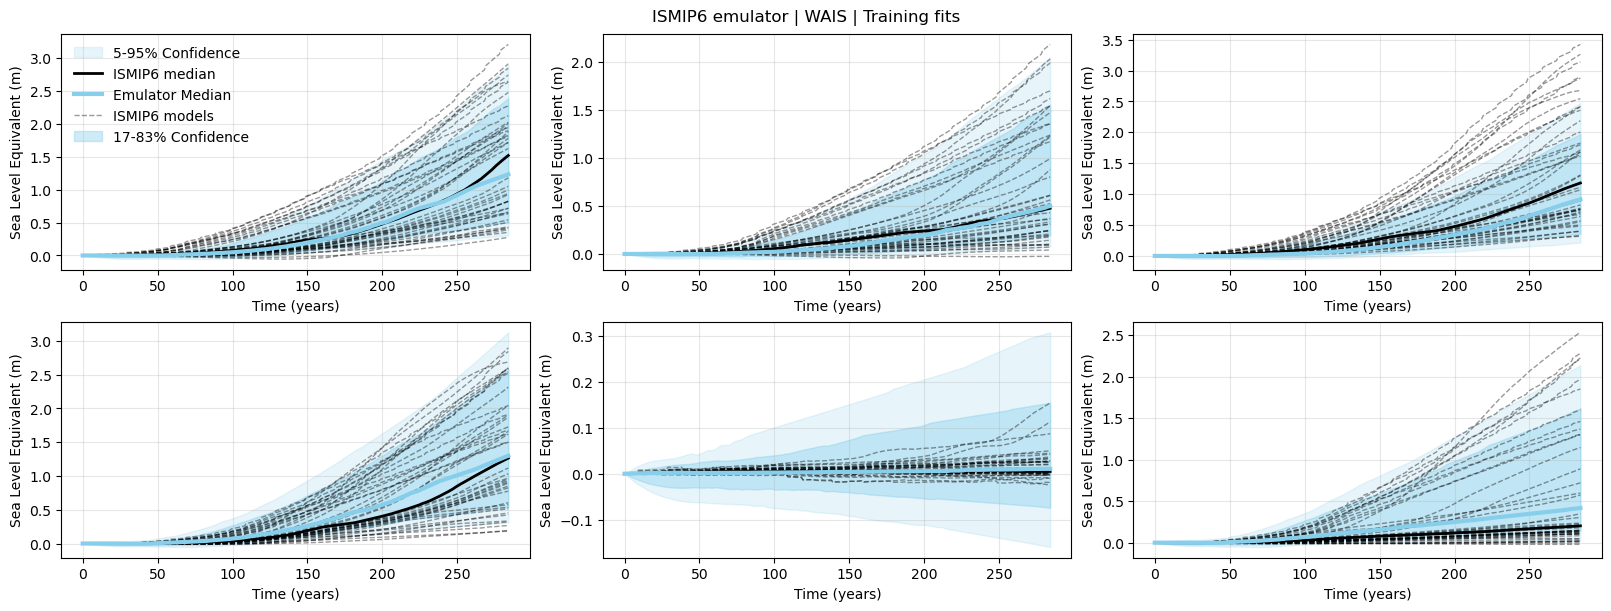

In [5]:
fig = plt.figure(figsize=(16, 6), layout="constrained")
fig.suptitle("ISMIP6 emulator | WAIS | Training fits")
for scen, _ in enumerate(wa_train_preds):
    ax = fig.add_subplot(2, 3, scen+1)
    p5 = np.percentile(wa_train_preds[scen], 5, axis=(0, 1))
    p17 = np.percentile(wa_train_preds[scen], 17, axis=(0, 1))
    median = np.median(wa_train_preds[scen], axis=(0, 1))
    p83 = np.percentile(wa_train_preds[scen], 83, axis=(0, 1))
    p95 = np.percentile(wa_train_preds[scen], 95, axis=(0, 1))

    true_median = np.percentile(train[1]["sle"][scen], 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='skyblue', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='skyblue', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (train[1]["sle"][scen].shape[0], 1)).T, train[1]["sle"][scen].T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='skyblue', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)

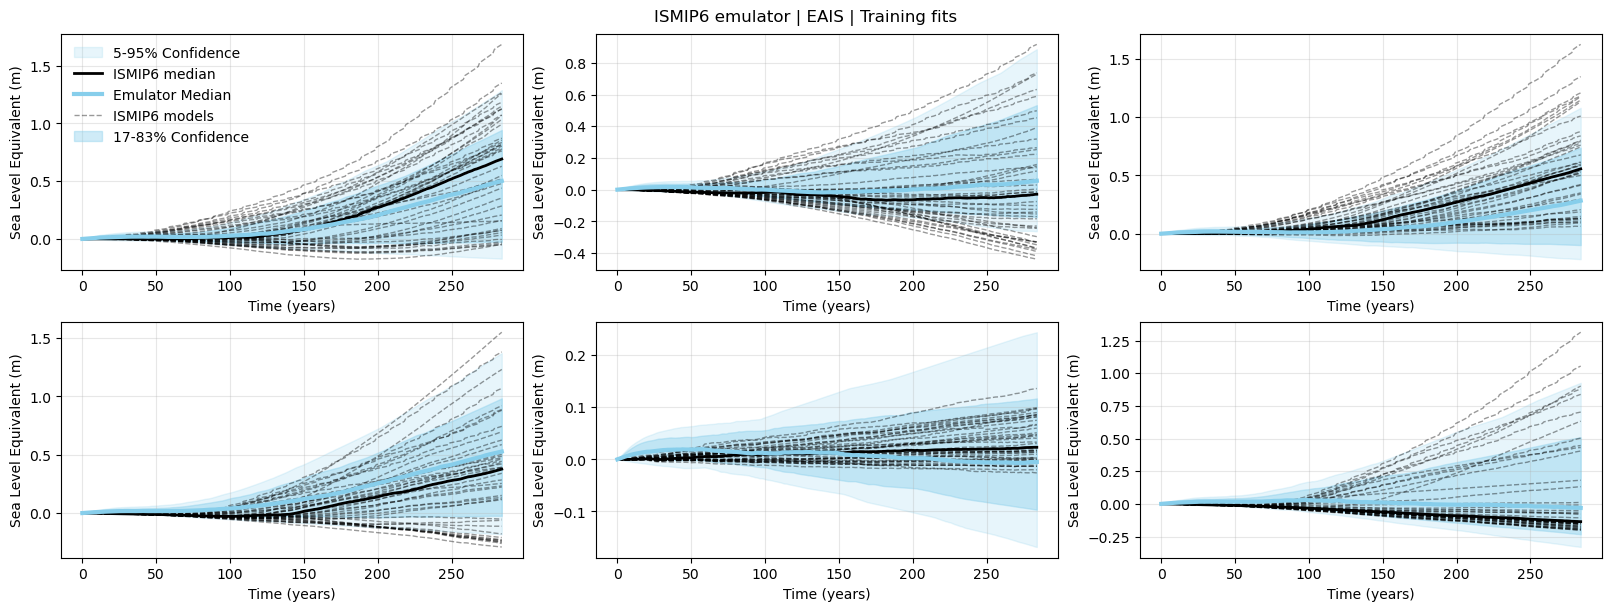

In [6]:
fig = plt.figure(figsize=(16, 6), layout="constrained")
fig.suptitle("ISMIP6 emulator | EAIS | Training fits")
for scen, _ in enumerate(ea_train_preds):
    ax = fig.add_subplot(2, 3, scen+1)
    p5 = np.percentile(ea_train_preds[scen], 5, axis=(0, 1))
    p17 = np.percentile(ea_train_preds[scen], 17, axis=(0, 1))
    median = np.median(ea_train_preds[scen], axis=(0, 1))
    p83 = np.percentile(ea_train_preds[scen], 83, axis=(0, 1))
    p95 = np.percentile(ea_train_preds[scen], 95, axis=(0, 1))

    true_median = np.percentile(train[2]["sle"][scen], 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='skyblue', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='skyblue', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (train[2]["sle"][scen].shape[0], 1)).T, train[2]["sle"][scen].T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='skyblue', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)

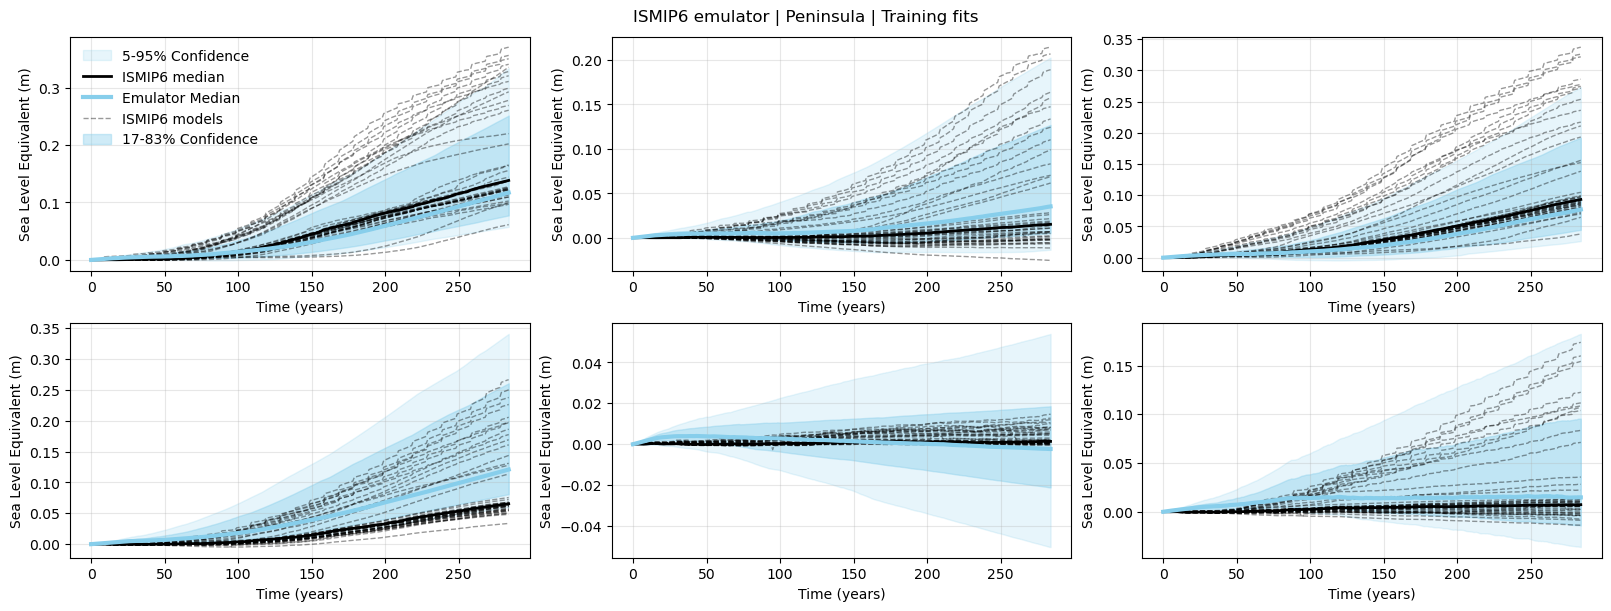

In [7]:
fig = plt.figure(figsize=(16, 6), layout="constrained")
fig.suptitle("ISMIP6 emulator | Peninsula | Training fits")
for scen, _ in enumerate(pen_train_preds):
    ax = fig.add_subplot(2, 3, scen+1)
    p5 = np.percentile(pen_train_preds[scen], 5, axis=(0, 1))
    p17 = np.percentile(pen_train_preds[scen], 17, axis=(0, 1))
    median = np.median(pen_train_preds[scen], axis=(0, 1))
    p83 = np.percentile(pen_train_preds[scen], 83, axis=(0, 1))
    p95 = np.percentile(pen_train_preds[scen], 95, axis=(0, 1))

    true_median = np.percentile(train[3]["sle"][scen], 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='skyblue', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='skyblue', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (train[3]["sle"][scen].shape[0], 1)).T, train[3]["sle"][scen].T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='skyblue', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)

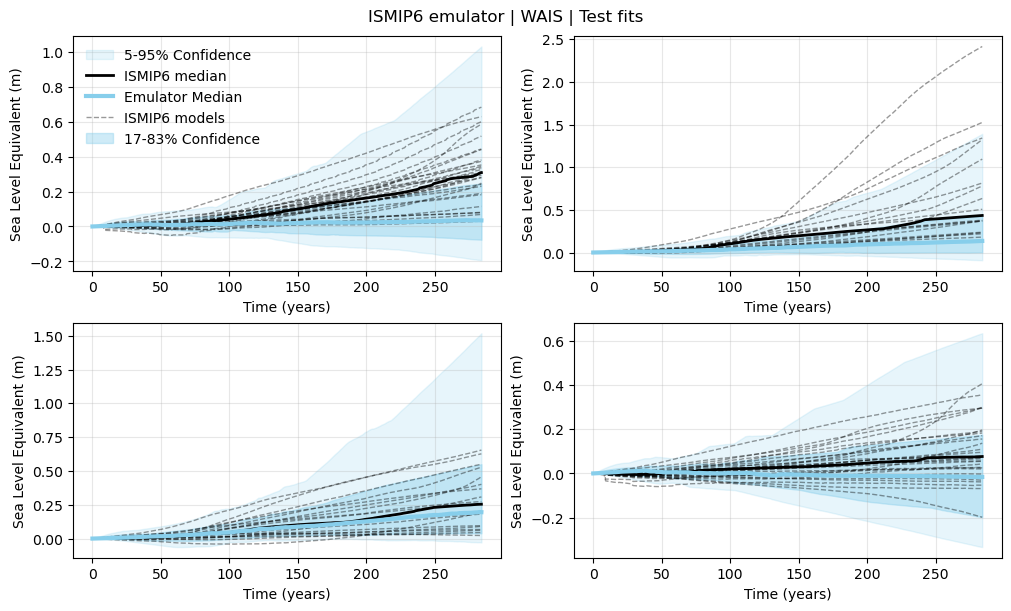

In [8]:
fig = plt.figure(figsize=(10, 6), layout="constrained")
fig.suptitle("ISMIP6 emulator | WAIS | Test fits")
for scen, _ in enumerate(wa_test_preds):
    ax = fig.add_subplot(2, 2, scen+1)
    p5 = np.percentile(wa_test_preds[scen], 5, axis=(0, 1))
    p17 = np.percentile(wa_test_preds[scen], 17, axis=(0, 1))
    median = np.median(wa_test_preds[scen], axis=(0, 1))
    p83 = np.percentile(wa_test_preds[scen], 83, axis=(0, 1))
    p95 = np.percentile(wa_test_preds[scen], 95, axis=(0, 1))

    true_median = np.percentile(test[1]["sle"][scen], 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='skyblue', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='skyblue', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (test[1]["sle"][scen].shape[0], 1)).T, test[1]["sle"][scen].T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='skyblue', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)

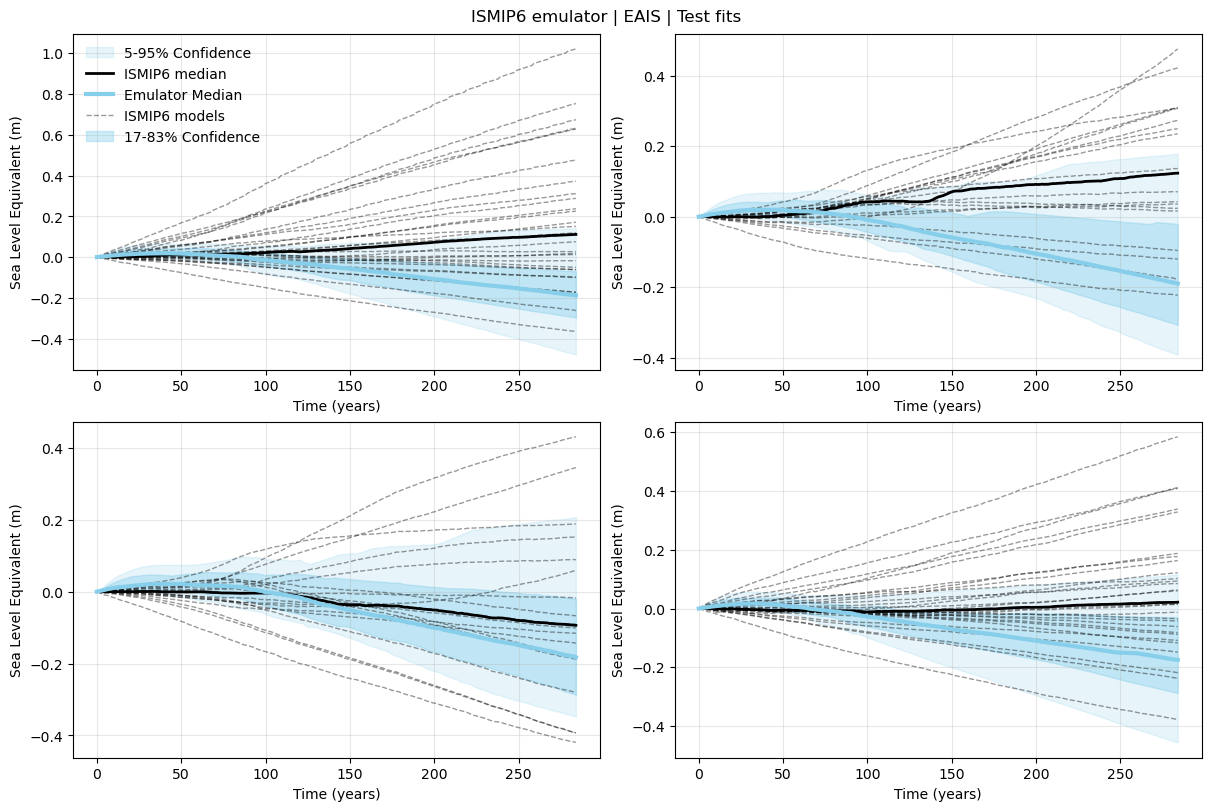

In [21]:
fig = plt.figure(figsize=(12, 8), layout="constrained")
fig.suptitle("ISMIP6 emulator | EAIS | Test fits")
for scen, _ in enumerate(ea_test_preds):
    ax = fig.add_subplot(2, 2, scen+1)
    p5 = np.percentile(ea_test_preds[scen], 5, axis=(0, 1))
    p17 = np.percentile(ea_test_preds[scen], 17, axis=(0, 1))
    median = np.median(ea_test_preds[scen], axis=(0, 1))
    p83 = np.percentile(ea_test_preds[scen], 83, axis=(0, 1))
    p95 = np.percentile(ea_test_preds[scen], 95, axis=(0, 1))

    true_median = np.percentile(test[2]["sle"][scen], 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='skyblue', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='skyblue', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (test[2]["sle"][scen].shape[0], 1)).T, test[2]["sle"][scen].T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='skyblue', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)

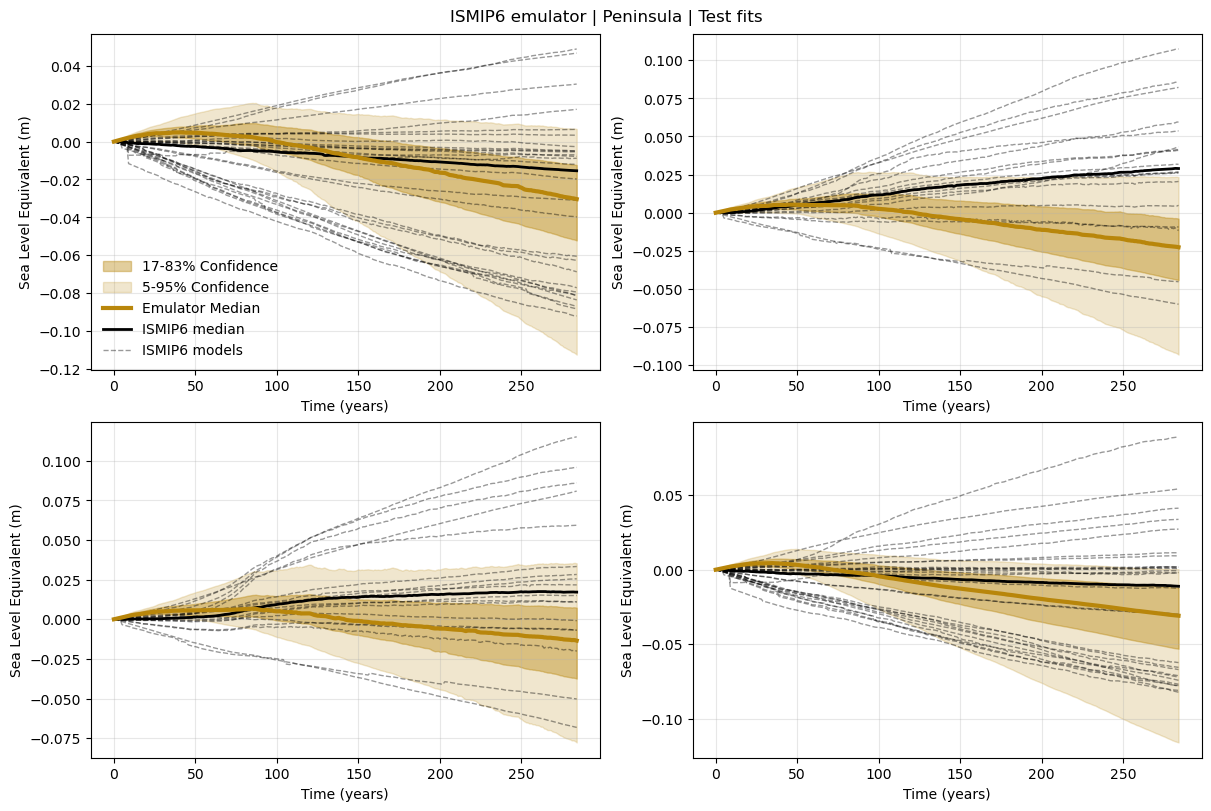

In [26]:
fig = plt.figure(figsize=(12, 8), layout="constrained")
fig.suptitle("ISMIP6 emulator | Peninsula | Test fits")
for scen, _ in enumerate(pen_test_preds):
    ax = fig.add_subplot(2, 2, scen+1)
    p5 = np.percentile(pen_test_preds[scen], 0, axis=(0, 1))
    p17 = np.percentile(pen_test_preds[scen], 17, axis=(0, 1))
    median = np.median(pen_test_preds[scen], axis=(0, 1))
    p83 = np.percentile(pen_test_preds[scen], 83, axis=(0, 1))
    p95 = np.percentile(pen_test_preds[scen], 95, axis=(0, 1))

    true_median = np.percentile(test[3]["sle"][scen], 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='darkgoldenrod', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='darkgoldenrod', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (test[3]["sle"][scen].shape[0], 1)).T, test[3]["sle"][scen].T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='darkgoldenrod', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = sorted(set(labels))
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='lower left')

    ax.grid(True, alpha=0.3)

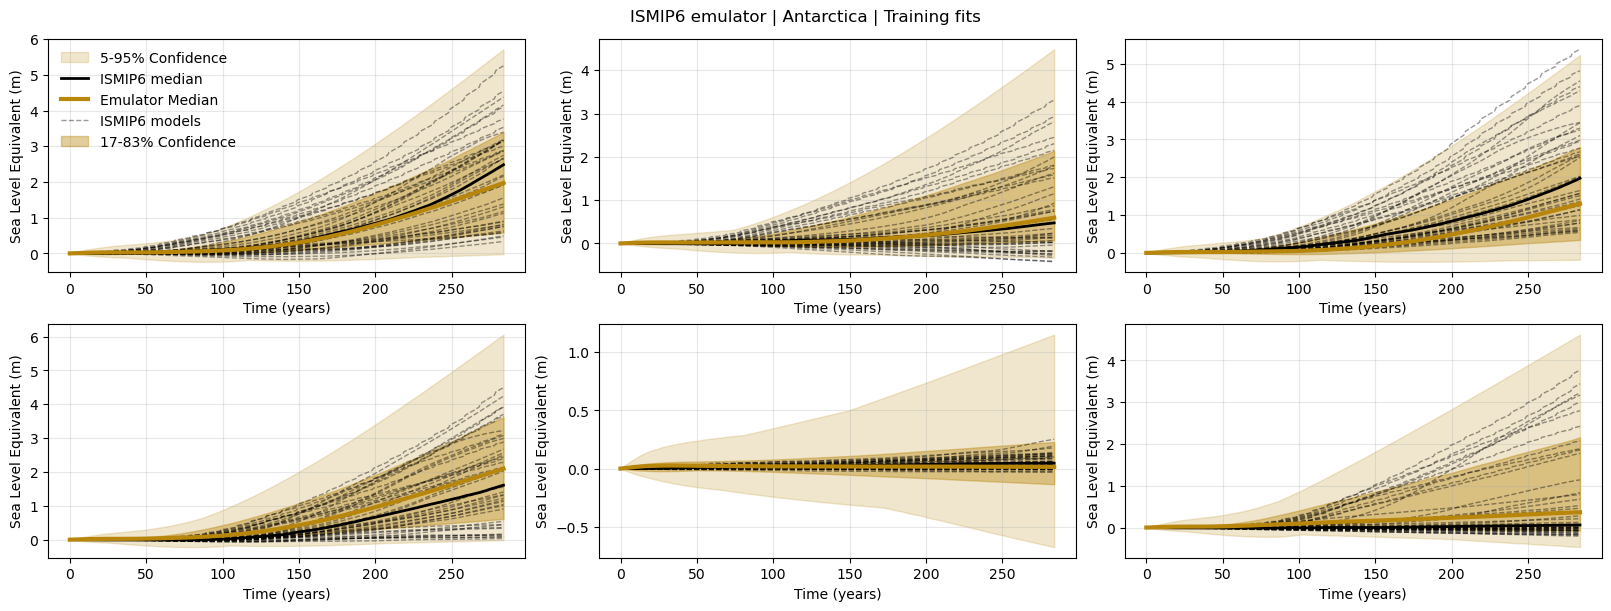

In [13]:
 # Now all together
fig = plt.figure(figsize=(16, 6), layout="constrained")
fig.suptitle("ISMIP6 emulator | Antarctica | Training fits")
for scen, _ in enumerate(pen_train_preds):
    sum_train_preds = wa_train_preds[scen] + ea_train_preds[scen] + pen_train_preds[scen]
    sum_train_ismip = train[1]["sle"][scen] + train[2]["sle"][scen] + train[3]["sle"][scen]
    
    ax = fig.add_subplot(2, 3, scen+1)
    p5 = np.percentile(sum_train_preds, 0, axis=(0, 1))
    p17 = np.percentile(sum_train_preds, 17, axis=(0, 1))
    median = np.median(sum_train_preds, axis=(0, 1))
    p83 = np.percentile(sum_train_preds, 83, axis=(0, 1))
    p95 = np.percentile(sum_train_preds, 100, axis=(0, 1))

    true_median = np.percentile(sum_train_ismip, 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='darkgoldenrod', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='darkgoldenrod', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (train[3]["sle"][scen].shape[0], 1)).T, sum_train_ismip.T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='darkgoldenrod', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)

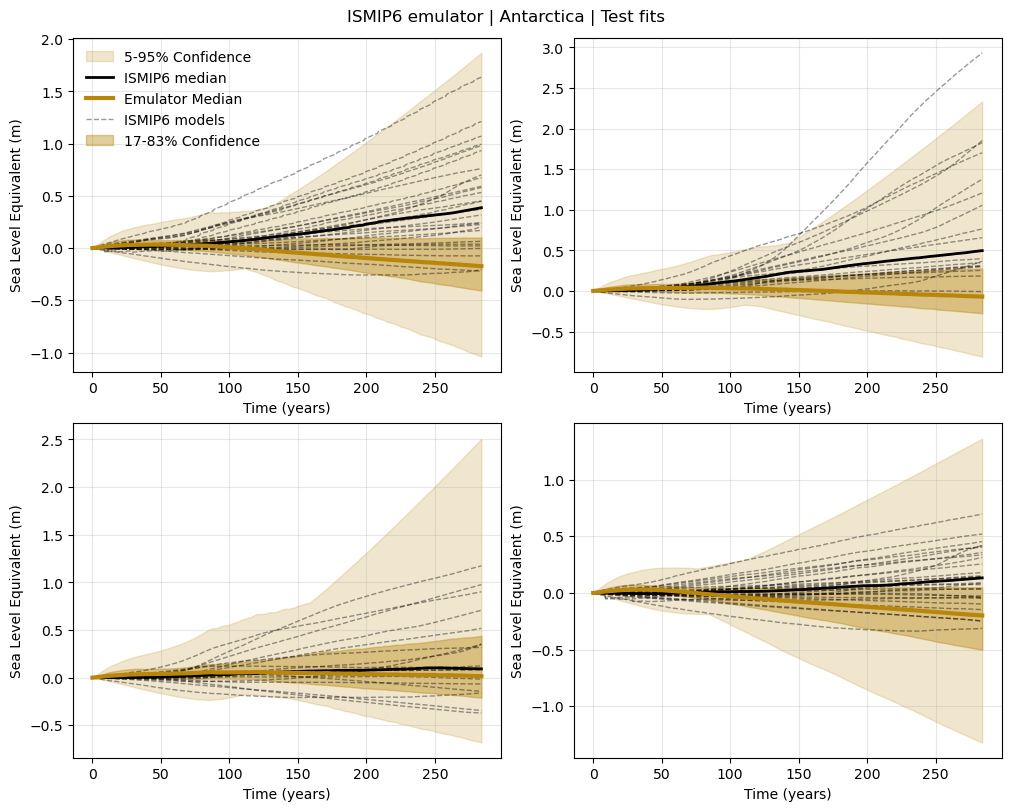

In [19]:
 # Now all together
fig = plt.figure(figsize=(10, 8), layout="constrained")
fig.suptitle("ISMIP6 emulator | Antarctica | Test fits")
for scen, _ in enumerate(pen_test_preds):
    sum_test_preds = wa_test_preds[scen] + ea_test_preds[scen] + pen_test_preds[scen]
    sum_test_ismip = test[1]["sle"][scen] + test[2]["sle"][scen] + test[3]["sle"][scen]

    ax = fig.add_subplot(2, 2, scen+1)
    p5 = np.percentile(sum_test_preds, 0, axis=(0, 1))
    p17 = np.percentile(sum_test_preds, 17, axis=(0, 1))
    median = np.median(sum_test_preds, axis=(0, 1))
    p83 = np.percentile(sum_test_preds, 83, axis=(0, 1))
    p95 = np.percentile(sum_test_preds, 100, axis=(0, 1))

    true_median = np.percentile(sum_test_ismip, 50, axis=0)

    time_axis = np.arange(len(median))

    # Plot Emulator Uncertainty
    ax.fill_between(time_axis, p5, p95, color='darkgoldenrod', alpha=0.2, label='5-95% Confidence')
    ax.fill_between(time_axis, p17, p83, color='darkgoldenrod', alpha=0.4, label='17-83% Confidence')


    ax.plot(np.tile(time_axis, (test[3]["sle"][scen].shape[0], 1)).T, sum_test_ismip.T, '--', lw=1, color="black", alpha=0.4, label="ISMIP6 models")
    ax.plot(time_axis, true_median, lw=2, color='black', label="ISMIP6 median")
    ax.plot(time_axis, median, color='darkgoldenrod', lw=3, label='Emulator Median')

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Sea Level Equivalent (m)")

    if scen == 0:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = set(labels)
        handles = [handles[labels.index(label)] for label in unique_labels if label in labels]
        ax.legend(handles, unique_labels, frameon=False, loc='upper left')

    ax.grid(True, alpha=0.3)